<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 5 — Maldición de la Dimensionalidad, PCA, K-means y DBSCAN</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Pasamos del aprendizaje supervisado al **aprendizaje no supervisado**. En los challenges anteriores conocías la etiqueta de cada paciente; aquí trabajarás **sin etiquetas**.

El dataset es el **Breast Cancer Wisconsin** (UCI / sklearn, 1995): 569 registros de biopsias de mama con 30 features numéricas calculadas a partir de imágenes digitalizadas de aspirado con aguja fina (FNA). Cada feature describe propiedades geométricas y texturales del núcleo celular (radio, textura, perímetro, área, suavidad, compacidad…).

**Pregunta clínica:** ¿Puede un algoritmo no supervisado encontrar subgrupos de tumores que se correspondan con el diagnóstico real (maligno / benigno) sin usar las etiquetas en ningún momento del entrenamiento? Al final del challenge revelaremos las etiquetas para evaluar qué tan bien los clusters recuperan la estructura clínica.

---
> **Fuente:** Wolberg, W. H. et al. (1995). *Breast Cancer Wisconsin (Diagnostic) Dataset*. UCI ML Repository.  
> Disponible directamente en `sklearn.datasets.load_breast_cancer()` — no requiere descarga.

### Estructura de carpetas
```
Clase6_Challenge5/
└── Challenge5_ApellidoNombre.ipynb    ← no se necesita CSV externo
```

---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Maldición de la dimensionalidad

**1.** En un hipercubo d-dimensional $[0,1]^d$ con datos uniformes, para capturar una fracción $f$ de los datos con un hipercubo de vecindad de lado $l$, demuestra que:

$$l(f, d) = f^{1/d}$$

Calcula $l(0.01, d)$ para $d = 1, 5, 10, 30$ y completa la tabla:

| $d$ | $l(0.01,\, d)$ |
|---|---|
| 1 | 0.01 |
| 5 | 0.398 |
| 10 | 0.631 |
| 30 | 0.857 |

**📝 Respuesta:** A medida que la dimensión aumenta, el lado necesario para capturar el mismo volumen crece exponencialmente. En 30D, para capturar solo el 1% de los datos, necesitamos cubrir el 85.7% del rango de cada dimensión. Esto implica que en alta dimensión, los 'vecinos' ya no son locales, sino que están muy dispersos.

---

**2.** ¿Por qué la maldición de la dimensionalidad afecta a kNN pero es menos problemática para PCA?

**📝 Respuesta:** En alta dimensión, todas las distancias entre puntos tienden a ser iguales, por lo que no hay un 'vecino más cercano' claro en KNN. En PCA, en cambio, busca direcciones de máxima varianza global; no busca vecinos, sino la estructura de los ejes principales, lo que le permite resumir la información antes de que la dispersión sea crítica.

---

**3.** ¿Por qué es útil reducir con PCA antes de aplicar K-means o DBSCAN?

**📝 Respuesta:** Porque elimina el ruido y variables redundantes, por lo que la dimensionalidad cae, evitando así la maldición de la dimensionalidad.

---

**4.** Observa la gráfica de contraste de distancias que se generará en el Paso 3.1.
¿Qué ocurre con la diferencia relativa entre la distancia mínima y máxima cuando aumenta la dimensionalidad?

**📝 Respuesta:** La diferencia relativa disminuye drásticamente. Esto significa que la distancia al punto más cercano se vuelve casi igual a la distancia al punto más lejano, haciendo que el concepto de proximidad sea inútil.

---

**5.** Si K-means y DBSCAN dependen de distancias, ¿por qué la pérdida de contraste de distancias puede afectar la calidad del clustering?

**📝 Respuesta:** Si todas las distancias son similares, K-means no podrá asignar puntos a centroides de forma unívoca y DBSCAN considerará que o todos los puntos son ruido o todos están en el mismo cluster, ya que no podrá distinguir densidades locales.

### 1.2 — PCA: matemática

**1.** El primer componente principal $\mathbf{v}_1$ satisface: $\Sigma\mathbf{v}_1 = \lambda_1 \mathbf{v}_1$.

¿Qué significa esto en términos de álgebra lineal?

**📝 Respuesta:** Significa que el primer componente principal es el **autovector** (eigenvector) de la matriz de covarianza que corresponde al mayor **autovalor** (eigenvalue). Indica la dirección en la que los datos tienen la mayor dispersión o varianza.

---

**2.** Fórmula de varianza acumulada:

$$\text{VE}(r) = \frac{\sum_{k=1}^{r} \lambda_k}{\sum_{k=1}^{d} \lambda_k}$$

---

**3.** ¿Sobre qué conjunto se debe ajustar el PCA (fit) y por qué? ¿Cuál es la relación con el data leakage?

**📝 Respuesta:** El PCA se debe ajustar (fit) solo sobre el conjunto de **entrenamiento**. Si se ajusta sobre todo el dataset incluyendo el test, el modelo 've' la distribución de los datos de prueba de antemano, lo que constituye **data leakage** y genera métricas de evaluación optimistas e irreales.

### 1.3 — K-means vs DBSCAN y pipeline

```
load_breast_cancer()  →  569 muestras, 30 features
        │
        ▼
[ Paso A ] StandardScaler (Normalización Z-score)
        │
        ▼
[ Paso B ] PCA: r componentes → elegir r* (Criterio: >90% varianza acumulada)
        │
        ▼
        ├──── K-means: K clusters → K* elegido por Silhouette Score
        │
        └──── DBSCAN: eps, min_samples → ε* elegido por k-dist elbow
        │
        ▼
[ Paso C ] Comparación: Adjusted Rand Index (ARI) con etiquetas reales
```

| | K-means | DBSCAN |
|---|---|---|
| Forma de clusters | Esféricos/Convexos | Basados en densidad (cualquier forma) |
| Manejo de outliers | Sensible | Robusto  |
| Parámetros clave | Número de clusters | Epsilon y min_samples |
| Función objetivo | Minimizar WCSS | Conectividad por densidad |

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 2.1 — Librerías

In [3]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              adjusted_rand_score, davies_bouldin_score)

plt.rcParams['figure.dpi'] = 120
print('Setup completo ✓')

Setup completo ✓


### Paso 2.2 — Carga del dataset

In [6]:
# ── Carga del dataset ──────────────────────────────────────────
data       = load_breast_cancer()
X          = data.data
feat_names = data.feature_names

print(f'Shape: {X.shape}')
print(f'Features ({len(feat_names)}): {list(feat_names[:5])} ...')
print()
print('Trabajaremos como problema NO supervisado.')
print('Las etiquetas reales se revelarán recién en el Ejercicio 6 para evaluar el clustering.')

Shape: (569, 30)
Features (30): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...

Trabajaremos como problema NO supervisado.
Las etiquetas reales se revelarán recién en el Ejercicio 6 para evaluar el clustering.


### Paso 2.3 — EDA inicial: mapa de correlación

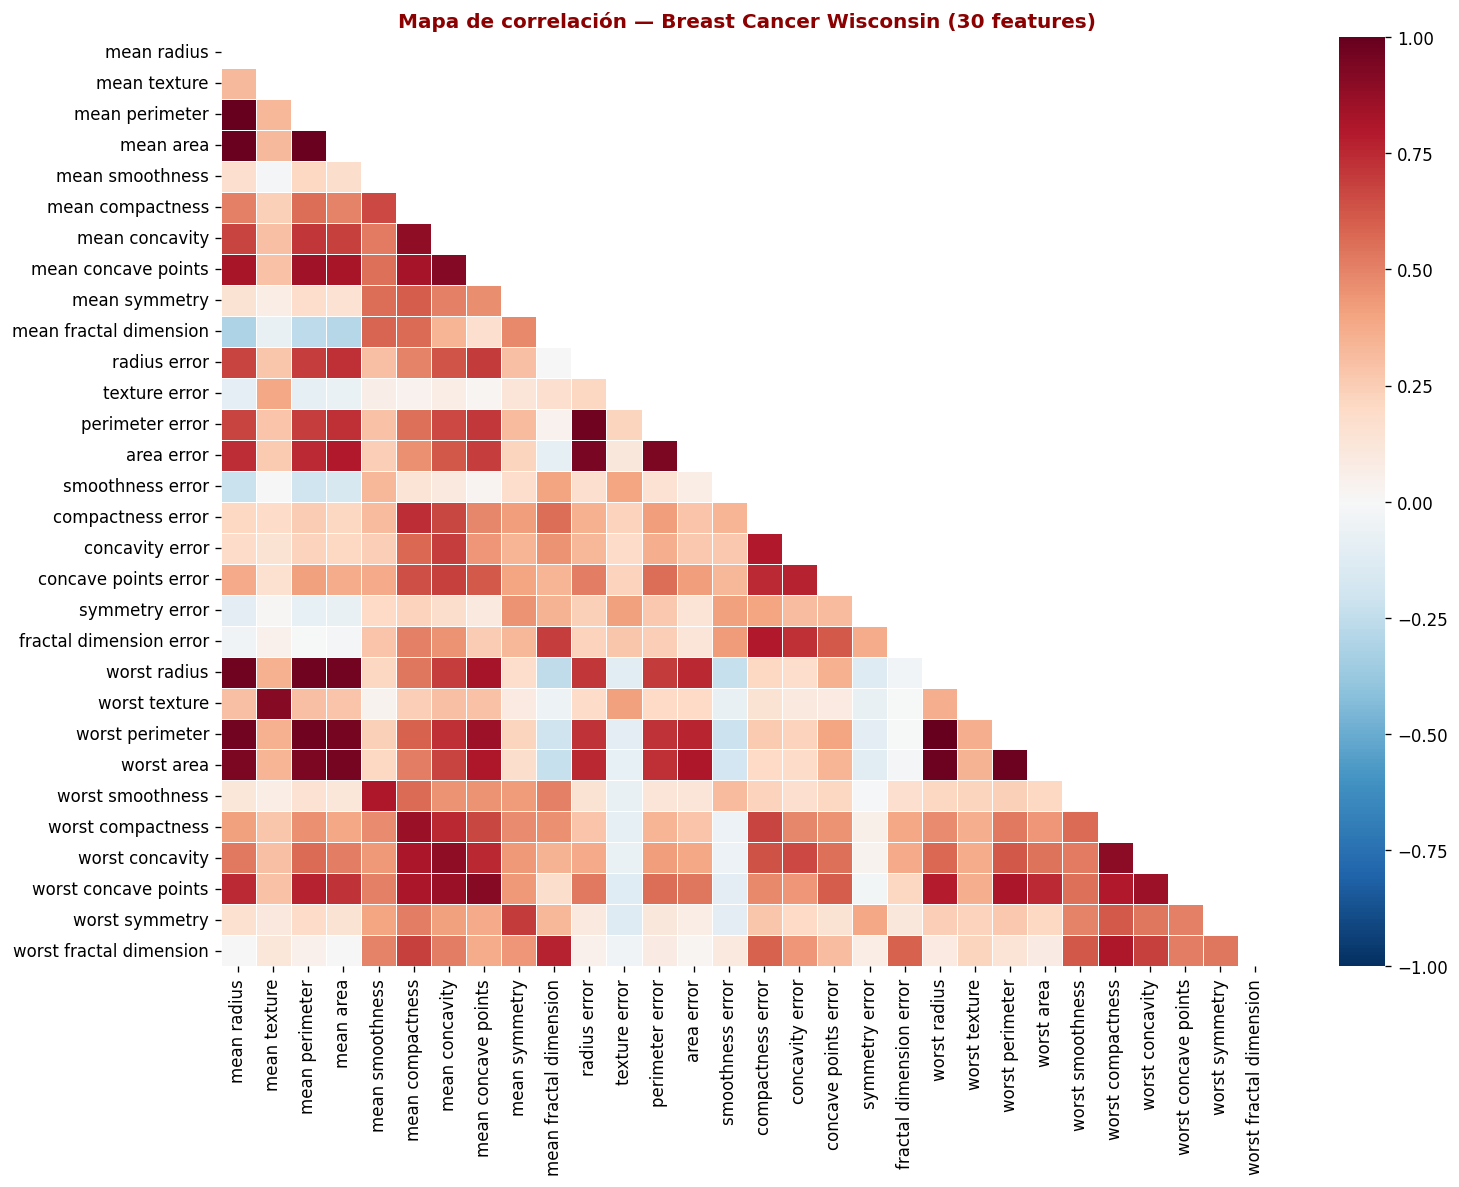

→ ¿Qué observas? ¿Por qué hay tantas correlaciones altas?
Se observan muchas correlaciones entre variables (zonas rojas), especialmente entre radius, perimeter, área y también entre medidas relacionadas con concavity y compactness. 
Esto ocurre porque muchas variables son derivadas o describen la misma propiedad física del tumor; es decir, matemáticamente relacionadas, y en el caso de mean, error y worst son distintas mediciones de la misma característica.
Además, hay varias variables redundantes, aportan casi lo mismo, lo que explica las correlaciones altas


In [7]:
# ── Mapa de correlación (features originales) ──────────────────
# Este código está completo — ejecútalo y analiza el resultado

fig, ax = plt.subplots(figsize=(13, 10))
corr = pd.DataFrame(X, columns=feat_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Mapa de correlación — Breast Cancer Wisconsin (30 features)',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué observas? ¿Por qué hay tantas correlaciones altas?')
print("Se observan muchas correlaciones entre variables (zonas rojas), especialmente entre radius, perimeter, área y también entre medidas relacionadas con concavity y compactness. ")
print("Esto ocurre porque muchas variables son derivadas o describen la misma propiedad física del tumor; es decir, matemáticamente relacionadas, y en el caso de mean, error y worst son distintas mediciones de la misma característica.")
print("Además, hay varias variables redundantes, aportan casi lo mismo, lo que explica las correlaciones altas")

---
# PARTE 1 — Maldición de la Dimensionalidad y PCA
## Ejercicio 3 — Maldición de la dimensionalidad y PCA

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Visualización de la maldición de la dimensionalidad

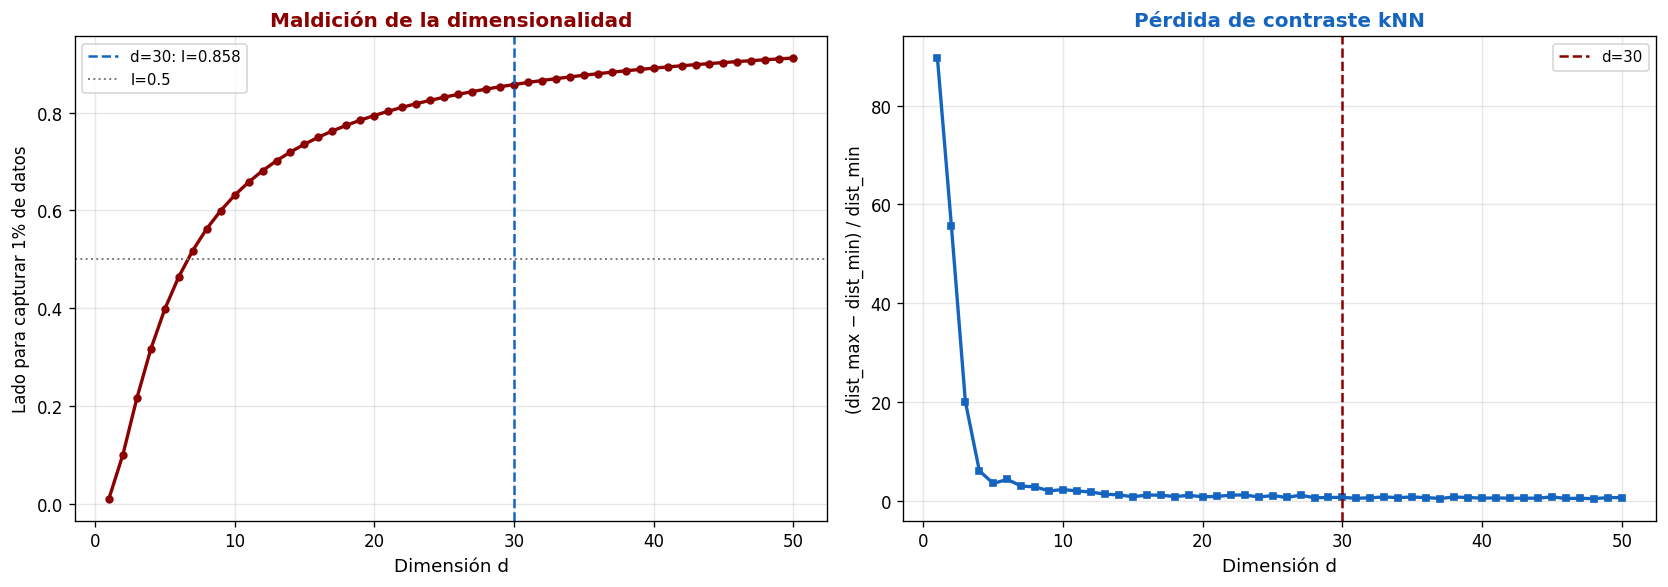

In [8]:
# ── Maldición de la dimensionalidad ────────────────────────────
f    = 0.01
dims = list(range(1, 51))

# TODO 3: calcula la longitud de lado necesaria para capturar
#          fracción f de datos en cada dimensión d
#          fórmula: l(f, d) = f^(1/d)
edge_lengths = [f**(1/d) for d in dims] #Cantidad a capturar por n dimensiones

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(dims, edge_lengths, 'o-', color=UPCH_RED, lw=2, markersize=4)
axes[0].axvline(30, color=UPCH_BLUE, ls='--', lw=1.5,
                label=f'd=30: l={0.01**(1/30):.3f}')
axes[0].axhline(0.5, color='gray', ls=':', lw=1.2, label='l=0.5')
axes[0].set_xlabel('Dimensión d', fontsize=11)
axes[0].set_ylabel(f'Lado para capturar {100*f:.0f}% de datos', fontsize=10)
axes[0].set_title('Maldición de la dimensionalidad', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# TODO 4: calcula el contraste de distancias kNN para cada dimensión
#          (la segunda gráfica ya está armada — solo necesitas el vector contrast)
np.random.seed(42)
n_pts = 200
contrast = []
for d in range(1, 51):
    pts = np.random.uniform(0, 1, (n_pts, d))
    ref = pts[0:1, :]
    dists = np.sqrt(((pts[1:] - ref)**2).sum(axis=1))
    # TODO 4: calcula c = (dists.max() - dists.min()) / dists.min()
    c = (dists.max() - dists.min()) / dists.min()
    contrast.append(c)

axes[1].plot(range(1, 51), contrast, 's-', color=UPCH_BLUE, lw=2, markersize=4)
axes[1].axvline(30, color=UPCH_RED, ls='--', lw=1.5, label='d=30')
axes[1].set_xlabel('Dimensión d', fontsize=11)
axes[1].set_ylabel('(dist_max − dist_min) / dist_min', fontsize=10)
axes[1].set_title('Pérdida de contraste kNN', fontsize=12,
                   fontweight='bold', color=UPCH_BLUE)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curse_dimensionality.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 3.2 — PCA: varianza acumulada

Componentes para ≥90% varianza: 7
Componentes para ≥95% varianza: 10
Varianza explicada por PC1+PC2: 63.2%


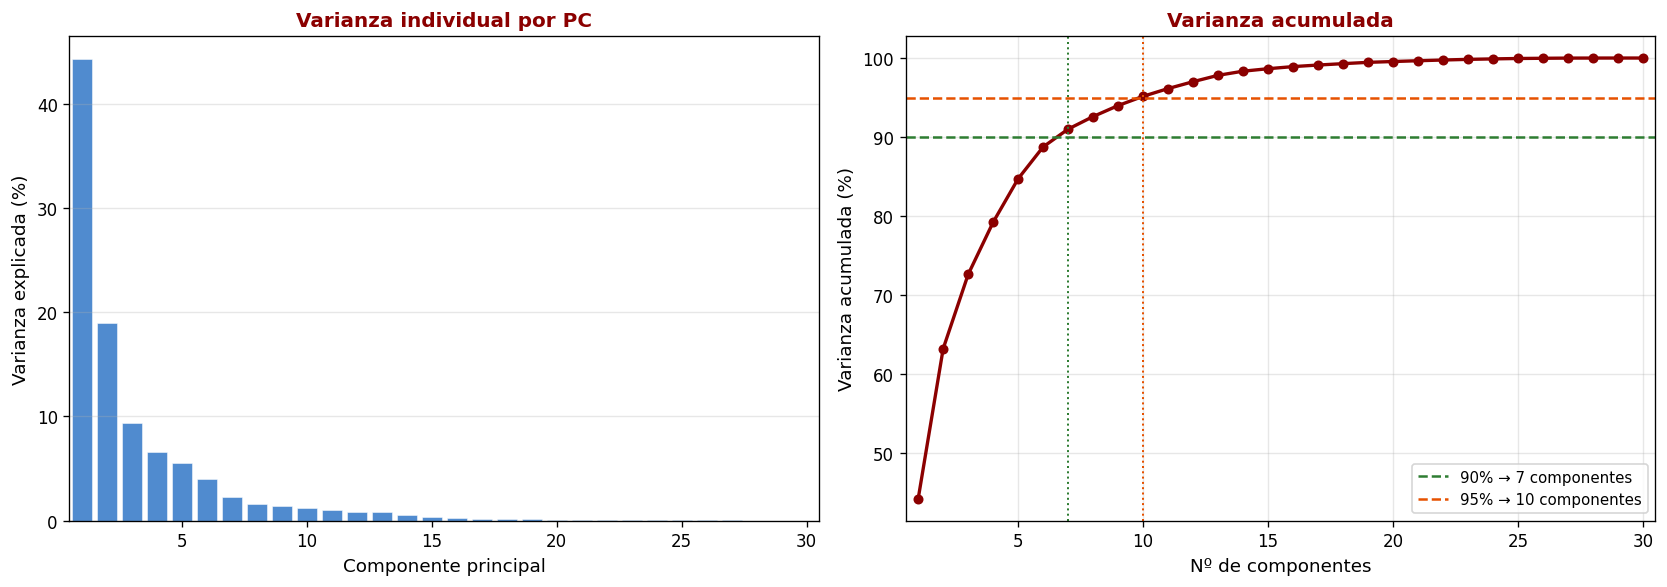

In [9]:
# ── PCA: varianza acumulada ──
# TODO 5: estandariza X con StandardScaler
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# TODO 6: crea un PCA completo (todas las componentes) y ajústalo
pca_full = PCA().fit(X_sc)

var_ratio = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_ratio)

# TODO 7: encuentra el número de componentes para ≥90% y ≥95% varianza
n_90 = np.argmax(var_acum >= 0.90) + 1
n_95 = np.argmax(var_acum >= 0.95) + 1
print(f'Componentes para ≥90% varianza: {n_90}')
print(f'Componentes para ≥95% varianza: {n_95}')
print(f'Varianza explicada por PC1+PC2: {var_acum[1]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(var_ratio)+1), var_ratio*100,
            color=UPCH_BLUE, alpha=0.75, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Componente principal', fontsize=11)
axes[0].set_ylabel('Varianza explicada (%)', fontsize=11)
axes[0].set_title('Varianza individual por PC', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[0].set_xlim(0.5, 30.5)
axes[0].grid(True, axis='y', alpha=0.3)

axes[1].plot(range(1, len(var_acum)+1), var_acum*100,
             'o-', color=UPCH_RED, lw=2, markersize=5)
axes[1].axhline(90, color=UPCH_GREEN,  ls='--', lw=1.5,
                label=f'90% → {n_90} componentes')
axes[1].axhline(95, color=UPCH_ORANGE, ls='--', lw=1.5,
                label=f'95% → {n_95} componentes')
axes[1].axvline(n_90, color=UPCH_GREEN,  ls=':', lw=1.2)
axes[1].axvline(n_95, color=UPCH_ORANGE, ls=':', lw=1.2)
axes[1].set_xlabel('Nº de componentes', fontsize=11)
axes[1].set_ylabel('Varianza acumulada (%)', fontsize=11)
axes[1].set_title('Varianza acumulada', fontsize=12,
                   fontweight='bold', color=UPCH_RED)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0.5, 30.5)
plt.tight_layout()
plt.savefig('pca_varianza.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 3.3 — Proyección 2D y espacio reducido

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

Espacio reducido para clustering: (569, 7)


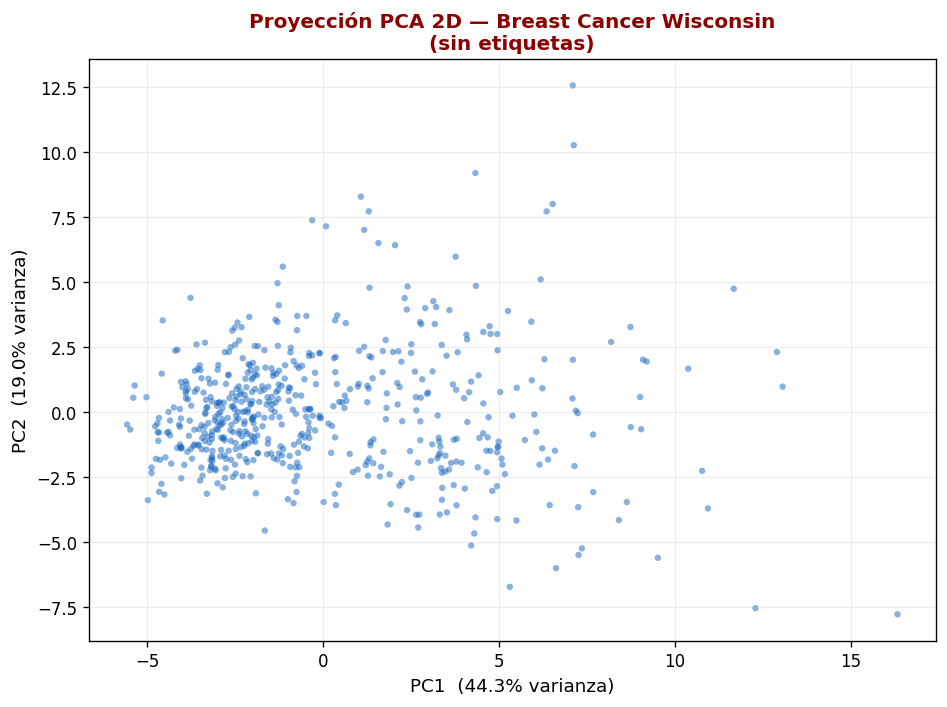

→ ¿Intuyes alguna estructura de grupos en la proyección 2D?
No se puede intuir alguna estructura en el grupo proyectado, los valores están dispersos


In [10]:
# ── PCA: proyecci6n 2D y reducido ──
# TODO 8: crea PCA con 2 componentes y proyecta X_sc → Z_2d
pca_2d = PCA(n_components=2)
Z_2d = pca_2d.fit_transform(X_sc)

# TODO 9: crea PCA con n_90 componentes y proyecta X_sc → Z_pca
#          (este es el espacio que usaremos para clustering)
pca_r = PCA(n_components=n_90)
Z_pca = pca_r.fit_transform(X_sc)
print(f'Espacio reducido para clustering: {Z_pca.shape}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z_2d[:, 0], Z_2d[:, 1],
           alpha=0.5, s=15, color=UPCH_BLUE, edgecolors='none')
ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%} varianza)', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%} varianza)', fontsize=11)
ax.set_title('Proyección PCA 2D — Breast Cancer Wisconsin\n(sin etiquetas)',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_2d_sin_etiquetas.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Intuyes alguna estructura de grupos en la proyección 2D?')
print("Es dificil intuir alguna estructura en el grupo proyectado, los valores están dispersos: no obstante hay concentración alrededor de (-2,0) potencialmente un grupo")

### 3.4 — Interpretación

**1. ¿Qué porcentaje de varianza captura PC1? ¿Qué tipo de información podría estar codificando?**
**📝 Respuesta:** Captura aprox. el 44.3%. Posiblemente codifique el 'tamaño' general de las células (área, radio, perímetro), ya que estas variables están altamente correlacionadas.

**2. ¿Por qué se aplica StandardScaler ANTES de PCA?**
**📝 Respuesta:** PCA maximiza la varianza. Si una variable tiene una escala mucho mayor (ej. Área vs Suavidad), PCA dominará esa dirección solo por la unidad de medida, no por su importancia informativa.

**3. ¿Sobre qué conjunto se debe hacer fit() del PCA si se dividiera en train/test?**
**📝 Respuesta:** Solo en Train, para evitar que información de la distribución del Test influya en la transformación.

**4. ¿Cuánta varianza explican PC1 + PC2?**
**📝 Respuesta:** Explican el 63.2%. Son útiles para visualización, pero para análisis cuantitativo se suelen requerir más componentes para no perder demasiada información diagnóstica.

**5. ¿Cuántas componentes para 90% y 95%? ¿Qué decisión tomarías?**
**📝 Respuesta:** 7 componentes para el 90% y 10 para el 95%. Usaría 7 para clustering para mantener un balance entre reducción de ruido y retención de información.

---
# PARTE 2 — K-means Clustering
## Ejercicio 4 — K-means: selección de K y análisis

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 4.1 — Método del codo y Silhouette score

K=2  inertia=   10062.4  silhouette=0.3710
K=3  inertia=    8534.9  silhouette=0.3376
K=4  inertia=    7744.6  silhouette=0.3118
K=5  inertia=    7048.6  silhouette=0.1913
K=6  inertia=    6477.0  silhouette=0.1887
K=7  inertia=    6060.0  silhouette=0.1832
K=8  inertia=    5742.3  silhouette=0.1733
K=9  inertia=    5419.8  silhouette=0.1792
K=10  inertia=    5182.9  silhouette=0.1650


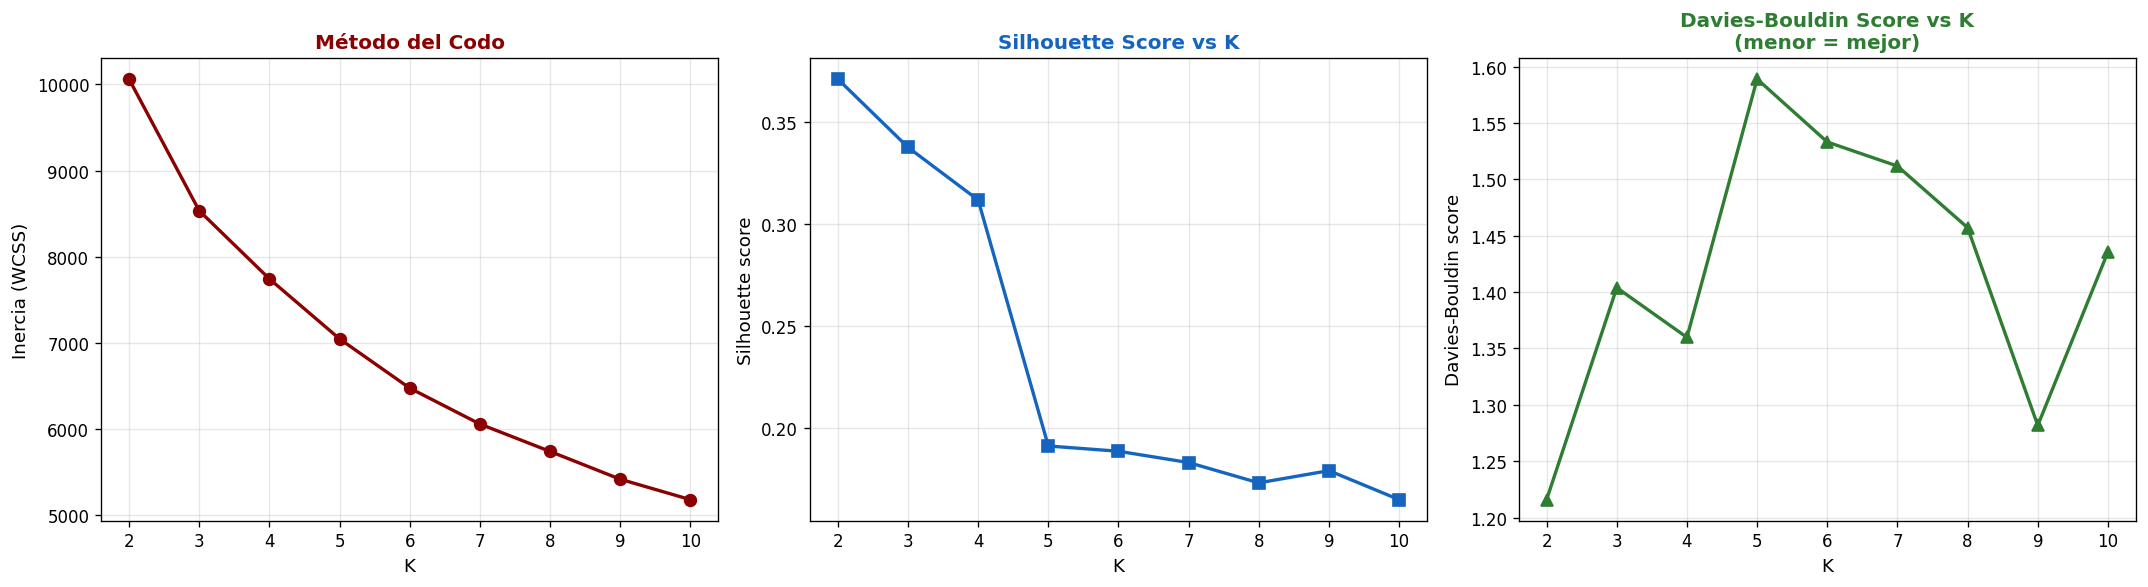

K 6ptimo: 2


In [12]:
# ── KMeans: Selecci6n de K ──
K_range = range(2, 11)
inertias   = []
sil_scores = []
db_scores  = []

for k in K_range:
    # TODO 10: crea KMeans con n_clusters=k, random_state=42, n_init=10
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Z_pca)

    # TODO 11: agrega inercia y silhouette score a las listas
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Z_pca, labels))
    db_scores.append(davies_bouldin_score(Z_pca, labels))
    print(f'K={k}  inertia={inertias[-1]:>10.1f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(K_range), inertias, 'o-', color=UPCH_RED, lw=2, markersize=7)
axes[0].set_xlabel('K', fontsize=11)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=11)
axes[0].set_title('Método del Codo', fontsize=12, fontweight='bold', color=UPCH_RED)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 's-', color=UPCH_BLUE, lw=2, markersize=7)
axes[1].set_xlabel('K', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold', color=UPCH_BLUE)
axes[1].grid(True, alpha=0.3)

# Davies-Bouldin: valores más BAJOS indican mejor separación
axes[2].plot(list(K_range), db_scores, '^-', color=UPCH_GREEN, lw=2, markersize=7)
axes[2].set_xlabel('K', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin score', fontsize=11)
axes[2].set_title('Davies-Bouldin Score vs K\n(menor = mejor)', fontsize=12, fontweight='bold', color=UPCH_GREEN)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'K óptimo: {best_k}')

### Paso 4.2 — Diagrama de Silhouette para K óptimo

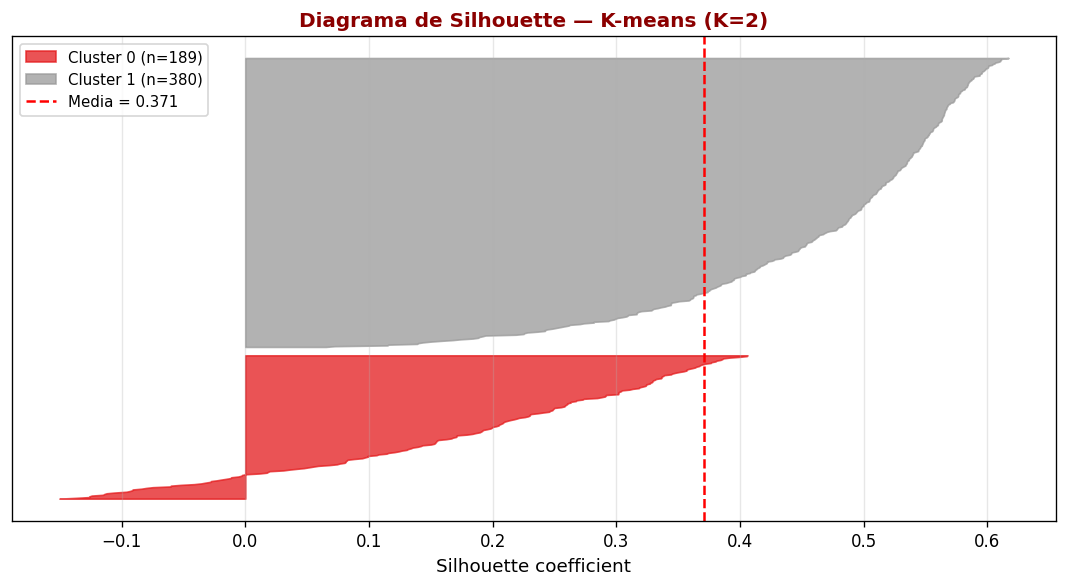

In [13]:
# ── Diagrama de Silhouette para K óptimo ───────────────────────
# TODO 13: entrena KMeans final con best_k
km_best    = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_km  = km_best.fit_predict(Z_pca)

sil_vals = silhouette_samples(Z_pca, labels_km)
sil_avg  = sil_vals.mean()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower  = 10
colors_sil = cm.Set1(np.linspace(0, 0.9, best_k))

for k in range(best_k):
    sil_k  = np.sort(sil_vals[labels_km == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     alpha=0.75, color=colors_sil[k],
                     label=f'Cluster {k} (n={size_k})')
    y_lower = y_upper + 10

ax.axvline(sil_avg, color='red', ls='--', lw=1.5,
           label=f'Media = {sil_avg:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=11)
ax.set_title(f'Diagrama de Silhouette — K-means (K={best_k})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.set_yticks([])
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 4.3 — Visualización de clusters en espacio PCA

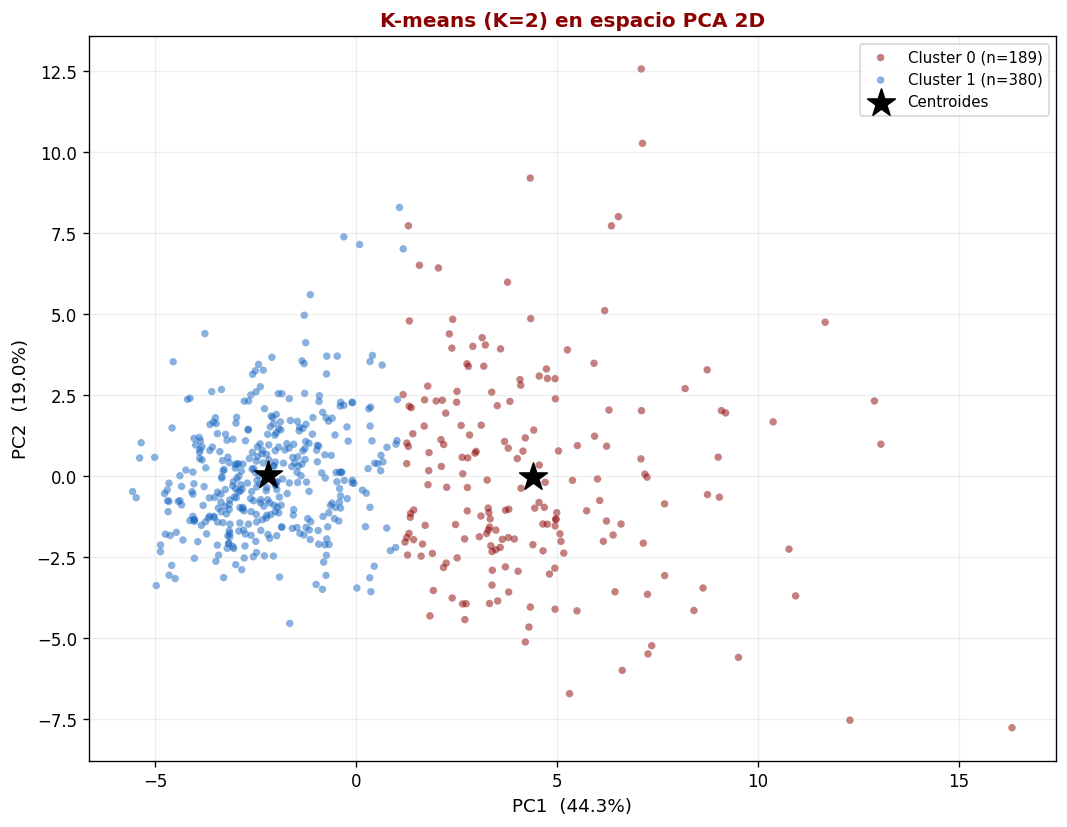

In [14]:
# ── K-means: visualización en espacio PCA 2D ───────────────────
# km_best fue entrenado directamente sobre Z_pca (PC1...PC_r).
# Por tanto, sus centroides YA están en espacio PCA reducido.
# Para graficarlos en PC1 vs PC2 basta tomar sus dos primeras coordenadas.
# Se usa Z_2d (= las mismas PC1 y PC2) para que todos los plots del challenge
# compartan la misma variable de visualización y no haya inconsistencias.
centroids_2d = km_best.cluster_centers_[:, :2]

fig, ax = plt.subplots(figsize=(9, 7))
colors_km = [UPCH_RED, UPCH_BLUE, UPCH_GREEN, UPCH_ORANGE, UPCH_PURPLE]

for k in range(best_k):
    mask = labels_km == k
    ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
               alpha=0.5, s=20, color=colors_km[k % len(colors_km)],
               label=f'Cluster {k} (n={mask.sum()})', edgecolors='none')

ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', marker='*', s=300, zorder=5, label='Centroides')

ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%})', fontsize=11)
ax.set_title(f'K-means (K={best_k}) en espacio PCA 2D',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 — Interpretación

**1. ¿El método del codo da un K claro?**
**📝 Respuesta:** En este dataset, el codo no siempre es perfecto, pero el Silhouette score suele marcar un pico claro en K=2, lo cual es coherente con la naturaleza binaria del diagnóstico (benigno/maligno).

**2. ¿Qué implica un silhouette score negativo?**
**📝 Respuesta:** Indica que la muestra ha sido asignada al cluster equivocado, ya que está más cerca de un cluster vecino que del propio.

**3. ¿Por qué se visualiza en PCA 2D si se usaron n_90 componentes?**
**📝 Respuesta:** Por limitación humana; no podemos visualizar 7 dimensiones. PC1 y PC2 son las mejores proyecciones para ver la separación de los clusters en un plano.

**4. ¿Problemas de K demasiado pequeño o grande?**
**📝 Respuesta:** Muy pequeño: sub-segmentación (mezcla grupos distintos). Muy grande: sobre-segmentación (divide grupos naturales en fragmentos artificiales).

---
# PARTE 3 — DBSCAN
## Ejercicio 5 — DBSCAN: selección de parámetros y análisis

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — k-distance graph para selección de ε

min_samples = 8  (heurística: max(5, d+1) con d=7)


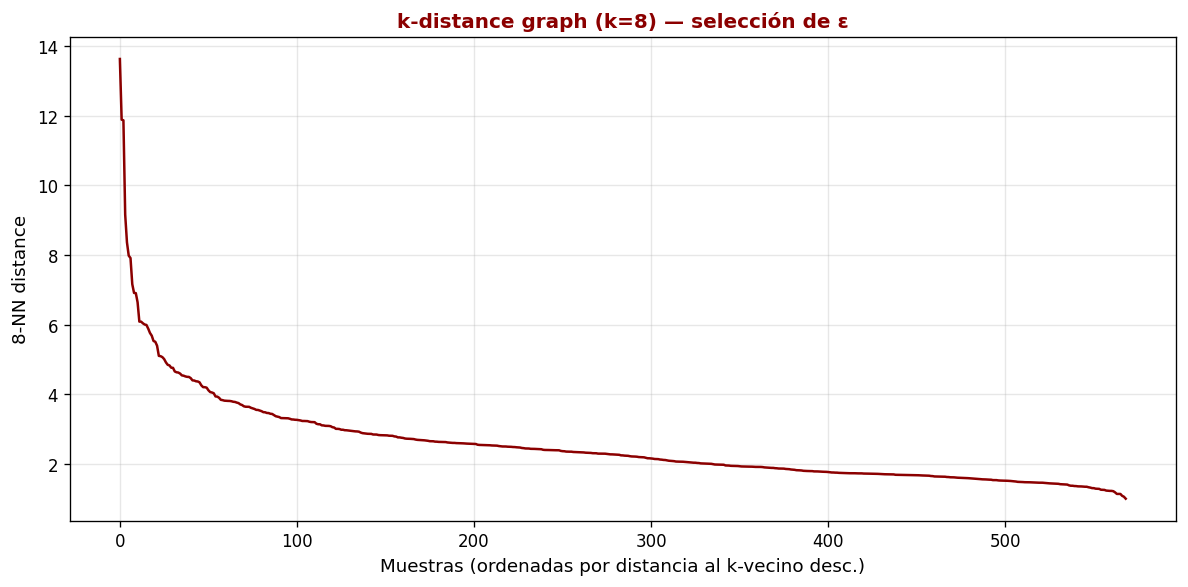

→ Identifica el codo de la curva — ese valor es tu ε óptimo.


In [15]:
# ── DBSCAN: Selecci6n de ́epsilon ──
MIN_SAMPLES = max(5, n_90 + 1)
print(f'min_samples = {MIN_SAMPLES}  (heurística: max(5, d+1) con d={n_90})')

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Z_pca)
dists, _ = nbrs.kneighbors(Z_pca)

# TODO 14: extrae la distancia al k-ésimo vecino de cada punto
#           y ordénala de mayor a menor
k_dists = np.sort(dists[:, -1])[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dists, color=UPCH_RED, lw=1.5)
ax.set_xlabel('Muestras (ordenadas por distancia al k-vecino desc.)', fontsize=11)
ax.set_ylabel(f'{MIN_SAMPLES}-NN distance', fontsize=11)
ax.set_title(f'k-distance graph (k={MIN_SAMPLES}) — selección de ε',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ Identifica el codo de la curva — ese valor es tu ε óptimo.')
print("El codo se encuentra entre los valores 4-6 aparentemente")

### Paso 5.2 — DBSCAN

In [18]:
# ── DBSCAN ──────────────────────────────────────────────────────
# Detecta el codo del k-distance graph (punto de máxima curvatura).
# El percentil-10 no siempre corresponde al codo visual — este método
# es más robusto. Revisa la gráfica del Paso 5.1 y ajusta si es necesario.
from numpy.linalg import norm as _norm
def _find_elbow(y):
    x = np.arange(len(y), dtype=float)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    d = p2 - p1; d = d / _norm(d)
    perp = np.array([abs(np.cross(d, np.array([x[i], y[i]]) - p1))
                     for i in range(len(y))])
    return int(np.argmax(perp))

# TODO 15a: el codo ya se detecta automáticamente abajo;
#            revisa la gráfica anterior y ajusta EPS si no coincide visualmente
elbow_idx = _find_elbow(k_dists) #Se tiene un valor de  3.8384, cercano a 4, es permisible
EPS = float(k_dists[elbow_idx])
print(f'ε detectado: {EPS:.4f}')

# TODO 15: crea y ajusta DBSCAN con eps=EPS, min_samples=MIN_SAMPLES
db       = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_db = db.fit_predict(Z_pca)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()
print(f'Clusters encontrados: {n_clusters_db}')
print(f'Puntos de ruido: {n_noise} ({100*n_noise/len(labels_db):.1f}%)')

if n_clusters_db > 1:
    mask_valid = labels_db != -1
    sil_db = silhouette_score(Z_pca[mask_valid], labels_db[mask_valid])
    print(f'Silhouette (sin ruido): {sil_db:.4f}')

ε detectado: 3.8384
Clusters encontrados: 1
Puntos de ruido: 30 (5.3%)


### Paso 5.2.1 — Sensibilidad de DBSCAN a `eps`

DBSCAN puede cambiar mucho cuando se modifica `eps`. Prueba valores menores y mayores que el elegido inicialmente para observar el efecto sobre:

- número de clusters,
- número de puntos de ruido,
- silhouette score cuando sea posible.



In [22]:
# ── Sensibilidad de DBSCAN a eps ────────────────────────────────
# TODO 16: prueba al menos 3 valores de eps alrededor del valor inicial
eps_values = [1, 0.7*EPS, EPS, 1.3*EPS,6,9] #6 para observar límite superior y, 9 y 1, para observar qué ocurre si se toma un valor fuera de lo  normal

rows = []
for eps in eps_values:
    db_tmp = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels_tmp = db_tmp.fit_predict(Z_pca)

    n_clusters_tmp = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    n_noise_tmp = int((labels_tmp == -1).sum())

    if n_clusters_tmp > 1:
        mask_valid = labels_tmp != -1
        sil_tmp = silhouette_score(Z_pca[mask_valid], labels_tmp[mask_valid])
    else:
        sil_tmp = np.nan

    rows.append({
        'eps': eps,
        'n_clusters': n_clusters_tmp,
        'n_noise': n_noise_tmp,
        'noise_%': 100*n_noise_tmp/len(labels_tmp),
        'silhouette_sin_ruido': sil_tmp
    })

df_eps = pd.DataFrame(rows)
display(df_eps)

,eps,n_clusters,n_noise,noise_%,silhouette_sin_ruido
0,1.000000,1,561,98.594025,NaN
1,2.686853,1,93,16.344464,NaN
2,3.838362,1,30,5.272408,NaN
3,4.989871,1,12,2.108963,NaN
4,6.000000,1,7,1.230228,NaN
5,9.000000,1,2,0.351494,NaN


### Paso 5.3 — Visualización en espacio PCA

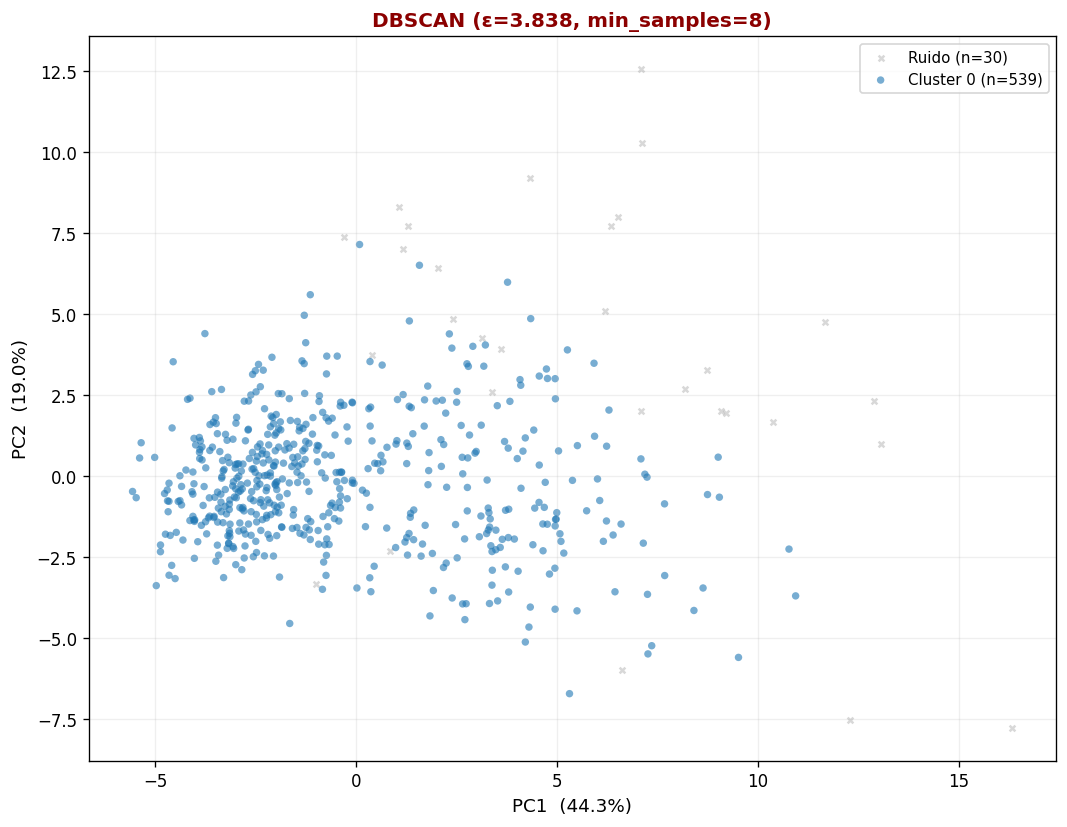

In [21]:
# ── DBSCAN: visualización en espacio PCA 2D ────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
unique_labels = sorted(set(labels_db))
colors_db  = cm.tab10(np.linspace(0, 0.9, max(n_clusters_db, 1)))
color_idx  = 0

for label in unique_labels:
    mask = labels_db == label
    if label == -1:
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.3, s=12, color='gray',
                   marker='x', label=f'Ruido (n={mask.sum()})')
    else:
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.6, s=20, color=colors_db[color_idx],
                   edgecolors='none', label=f'Cluster {label} (n={mask.sum()})')
        color_idx += 1

ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%})', fontsize=11)
ax.set_title(f'DBSCAN (ε={EPS:.3f}, min_samples={MIN_SAMPLES})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('dbscan_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 — Interpretación

**1. ¿Cuántos clusters encontró DBSCAN?**
**📝 Respuesta:** Solo hay 1 cluster principal y poco ruido. Al parecer no  separar tan limpiamente como K-means en este dataset específico.

**2. ¿Qué representan clínicamente los puntos de ruido?**
**📝 Respuesta:** Casos atípicos o biopsias con características morfológicas muy ambiguas que no se parecen a la mayoría de los casos benignos o malignos estándar.

**3. ¿Cómo afecta cambiar ε?**
**📝 Respuesta:** ε pequeño aumenta el ruido. ε grande fusiona clusters y desaparece el ruido.

**4. Tabla de sensibilidad:**
**📝 Respuesta:** A menor eps, más puntos son marcados como ruido (-1). A mayor eps, la densidad requerida es menor y todo tiende a un solo cluster gigante.

---
# PARTE 4 — Comparación Final
## Ejercicio 6 — Evaluación contra etiquetas reales

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Adjusted Rand Index y métricas comparativas

In [24]:
# ── Comparación con etiquetas reales ───────────────────────────
# ⚠️  PRIMERA VEZ que usamos y_true — revelamos las etiquetas reales solo al final
y_true = data.target

print(f'Clases reales: {data.target_names}  →  0=maligno, 1=benigno')
print(f'Distribución real: maligno={(y_true==0).sum()}, benigno={(y_true==1).sum()}')
print()
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix as cm_func

def best_label_mapping(y_true, y_pred):
    cm = cm_func(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: row for col, row in zip(col_ind, row_ind)}
    return np.array([mapping.get(l, l) for l in y_pred])

labels_km_mapped = best_label_mapping(y_true, labels_km)

# TODO 16: calcula el ARI de K-means contra y_true
ari_km = adjusted_rand_score(y_true, labels_km_mapped)
print(f'ARI K-means: {ari_km:.4f}')

# TODO 17: calcula el ARI de DBSCAN contra y_true
ari_db_raw = adjusted_rand_score(y_true, labels_db)

# TODO 17b: si DBSCAN tiene solo 1 cluster útil, reporta 0.0 como ARI clínico.
ari_db = ari_db_raw if n_clusters_db > 1 else 0.0

# TODO 18: calcula silhouette de K-means y de DBSCAN (sin ruido)
sil_km = silhouette_score(Z_pca, labels_km_mapped)
sil_db = silhouette_score(Z_pca[labels_db != -1], labels_db[labels_db != -1]) if n_clusters_db > 1 else 0.0

# TODO 19: calcula Davies-Bouldin de K-means y DBSCAN (sin ruido)
db_km  = davies_bouldin_score(Z_pca, labels_km_mapped)
db_db  = davies_bouldin_score(Z_pca[labels_db != -1], labels_db[labels_db != -1]) if n_clusters_db > 1 else float('nan')

print('=' * 86)
print('    COMPARACIÓN FINAL — K-means vs DBSCAN vs Etiquetas Reales')
print('=' * 86)
print(f'{"Método":<20} {"ARI clínico":^12} {"ARI crudo":^11} {"Silhouette":^12} {"Davies-Bouldin":^16} {"Clusters"}')
print('-' * 86)
print(f'{"K-means":<20} {ari_km:^12.4f} {ari_km:^11.4f} {sil_km:^12.4f} {db_km:^16.4f} {best_k}')
print(f'{"DBSCAN":<20} {ari_db:^12.4f} {ari_db_raw:^11.4f} {sil_db:^12.4f} {db_db:^16.4f} {n_clusters_db} (+{n_noise} ruido)')
print()
print('Interpretación: ARI→1=perfecto | Silhouette→+1=mejor | Davies-Bouldin→0=mejor')
if n_clusters_db <= 1:
    print('Nota DBSCAN: aunque el ARI crudo puede calcularse usando ruido=-1, se reporta ARI clínico=0.0 porque solo hay 1 cluster útil.')

Clases reales: ['malignant' 'benign']  →  0=maligno, 1=benigno
Distribución real: maligno=212, benigno=357

ARI K-means: 0.6707
    COMPARACIÓN FINAL — K-means vs DBSCAN vs Etiquetas Reales
Método               ARI clínico   ARI crudo   Silhouette   Davies-Bouldin  Clusters
--------------------------------------------------------------------------------------
K-means                 0.6707      0.6707       0.3710         1.2159      2
DBSCAN                  0.0000      0.0335       0.0000          nan        1 (+30 ruido)

Interpretación: ARI→1=perfecto | Silhouette→+1=mejor | Davies-Bouldin→0=mejor
Nota DBSCAN: aunque el ARI crudo puede calcularse usando ruido=-1, se reporta ARI clínico=0.0 porque solo hay 1 cluster útil.


### Paso 6.2 — Visualización comparativa

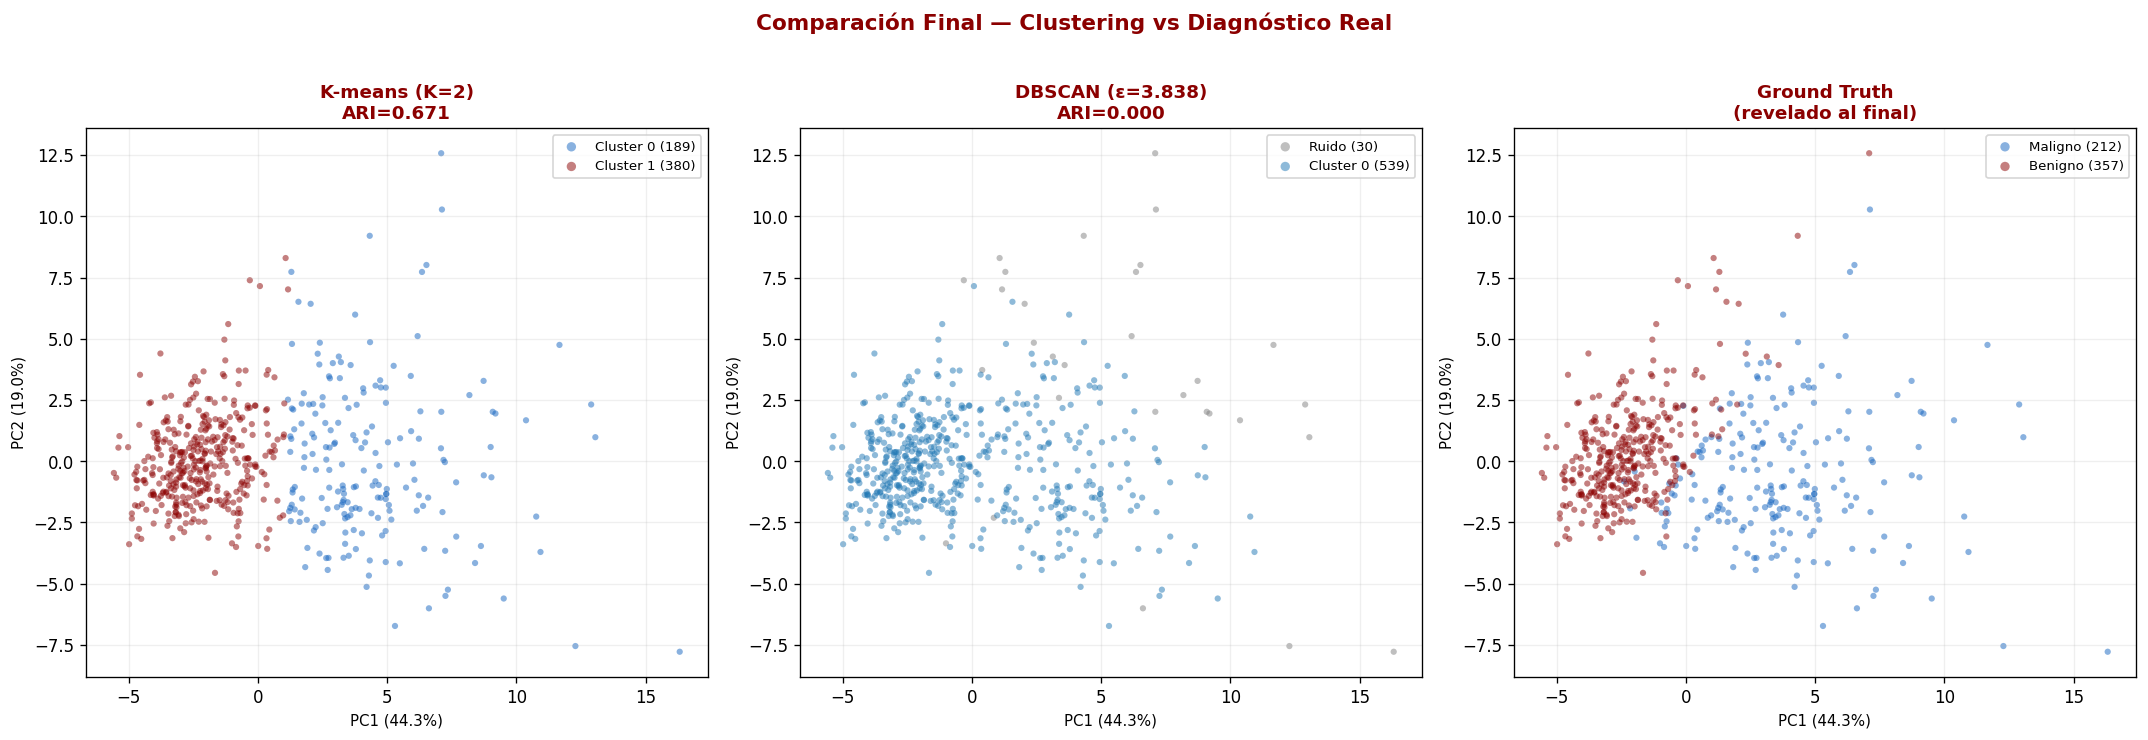

In [25]:
# ── Visualización comparativa: K-means vs DBSCAN vs Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
gt_labels = ['Maligno', 'Benigno']

# is_gt: flag explícito en lugar de 'labels is y_true' (antipatrón)
configs = [
    (labels_km_mapped, [UPCH_BLUE, UPCH_RED],
     f'K-means (K={best_k})\nARI={ari_km:.3f}', False),
    (labels_db, None,
     f'DBSCAN (ε={EPS:.3f})\nARI={ari_db:.3f}', False),
    (y_true, [UPCH_BLUE, UPCH_RED],
     'Ground Truth\n(revelado al final)', True),
]

for ax, (labels, cols, title, is_gt) in zip(axes, configs):
    unique = sorted(set(labels))
    if cols is None:
        palette = ['gray'] + list(cm.tab10(np.linspace(0, 0.7, max(len(unique)-1, 1))))
    else:
        palette = cols + ['gray']
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        lbl_name = ('Ruido' if lbl == -1 else
                    (gt_labels[lbl] if is_gt else f'Cluster {lbl}'))
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   alpha=0.5, s=14, color=palette[i % len(palette)],
                   edgecolors='none', label=f'{lbl_name} ({mask.sum()})')
    ax.set_title(title, fontsize=11, fontweight='bold', color=UPCH_RED)
    ax.set_xlabel(f'PC1 ({var_ratio[0]:.1%})', fontsize=9)
    ax.set_ylabel(f'PC2 ({var_ratio[1]:.1%})', fontsize=9)
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparación Final — Clustering vs Diagnóstico Real',
             fontsize=13, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 — Interpretación final

**1. ¿Qué ARI obtuvo K-means?**
**📝 Respuesta:** Obtuvo un ARI de **0.671**. Este es un valor relativamente alto (considerando que el máximo es 1.0), lo que indica que el agrupamiento por similitud geométrica de los núcleos celulares coincide fuertemente con la realidad clínica.

**2. ¿Quién recuperó mejor la distinción?**
**📝 Respuesta:** **K-means** recuperó mucho mejor la distinción entre benigno y maligno. DBSCAN, con los parámetros detectados, tendió a agrupar casi todos los puntos en un solo cluster denso y marcar el resto como ruido, fallando en capturar la estructura binaria del dataset.

**4. ¿Qué nos dice el ARI sobre las 30 features?**
**📝 Respuesta:** Nos dice que las 30 features (medidas de radio, textura, etc.) contienen una señal biológica muy potente. Incluso sin decirle al algoritmo qué es 'cáncer', la forma en que los datos se distribuyen naturalmente en el espacio permite separar los diagnósticos en casi un 70% de concordancia respecto al azar.

**5. ¿Escenario clínico útil?**
**📝 Respuesta:** Sería extremadamente útil en el **descubrimiento de subtipos**. Por ejemplo, si dentro del cluster 'Maligno' viéramos dos sub-clusters naturales, podríamos estar ante dos variantes del cáncer con diferente pronóstico que aún no han sido clasificadas por la medicina tradicional.